### Домашнее задание 4 - 10 баллов

В этом задании вам предстоит обучить трансформерную модель для классификации текстов разными способами и сравнить их эффективность.

1. Выберите набор данных для классификации текстов из HuggingFace Datasets - **0.5 балла**
2. Выберите модель архитектуры, подходящей для задачи классификации, в HuggingFace Hub (убедитесь, что она поддерживает язык вашего датасета) - **0.5 балла**
3. Измерьте качество классификации моделью as-is перед дообучением, с учетом метрик, специфичных для задачи классификации (trainer.evaluate) - **1 балл**
4. Дообучите выбранную модель полностью - full finetuning - **2 балла**
5. Дообучите модель в режиме linear probing - дообучите только дефолтный классификационный слой (или кастомную голову, если хотите) - **1 балл**
6. Дообучите модель с LoRA - **2 балла**
7. Сравните между собой полученные модели по итоговым метрикам, характеру сходимости, времени обучения - **1 балл**


**Общее**

- Принимаемые решения обоснованы (почему выбрана определенная архитектура/гиперпараметр/оптимизатор/преобразование и т.п.) - **1 балл**
- Обеспечена воспроизводимость решения: зафиксированы random_state, ноутбук воспроизводится от начала до конца без ошибок - **1 балл**

# Настройка окружения

In [1]:
%%capture
%pip install transformers datasets accelerate peft evaluate scikit-learn matplotlib

In [12]:
import os
import time
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from peft import get_peft_model, LoraConfig, TaskType
import evaluate
from dataclasses import dataclass
from typing import Any, Dict, List, Tuple
from sklearn.metrics import accuracy_score, f1_score

def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # When running on the CuDNN backend, two further options must be set
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set as {seed}")



SEED=42
set_seed(SEED)

# os.environ['TOKENIZERS_PARALLELISM'] = 'false'
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)
print("torch:", torch.__version__)

Random seed set as 42
device: cuda
torch: 2.9.0+cu126


In [3]:
from google import colab
colab.drive.mount('/content/drive')

Mounted at /content/drive


# Выбор набора данных

Используем ai-forever/kinopoisk-sentiment-classification - русскоязычные отзывы
с 3 классами тональности.


In [13]:
DATASET_NAME = 'ai-forever/kinopoisk-sentiment-classification'


ds: DatasetDict = load_dataset(DATASET_NAME)
ds


DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 10500
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 1500
    })
})

In [14]:
labels = sorted(set(ds['train']['label']))
label_texts = sorted(set(ds['train']['label_text']))
print('labels:', labels)
print('label_texts:', label_texts)


labels: [0, 1, 2]
label_texts: ['Bad', 'Good', 'Neutral']


In [15]:
# Посмотрим пример
ds['train'][0]


{'id': '0',
 'text': 'Если честно, меня не очень впечатлила новость, о том, что Гай Ричи собирается снять фильм, о Шерлоке Холмсе. Подумал — да это же будет: Карты, деньги, два ствола — у Холмса и у Ватсона. Но затем по мере появления трейлеров, и большей информации поменял своё отношение.\n«Шерлок Холмс» — последняя картина, на которую я планировал пойти в этом году. Жутко боялся, что она меня разочарует т. к. перед этим были расстроившие «Безумный спецназ», «Так себе каникулы» и немного 2012. Но Холмс полностью оправдал доверия.\nСюжет\nВ ленте динамичный, а главное интересный и захватывающий сюжет, что в последнее время не так уж и часто. Новый Холмс не поход классический образ представленный в картинах Игоря Масленникова, но это не портит его образ. Он больше подобен на Тони Старку из «Железного человека» или Грегори Хаусу из сериала «Доктор Хаус». Как и они, он весьма харизматичен, слегка безумен, но гениален в своём любимом деле.\nНа первый взгляд сюжет портит сверхъестественное 

# Выбор модели

Выбор: sergeyzh/rubert-tiny-turbo.

Почему:
- поддерживает русский язык
- BERT-подобная архитектура удобна для sequence classification
- маленький размер ускоряет эксперименты

In [16]:
MODEL_NAME = 'sergeyzh/rubert-tiny-turbo'
# MODEL_NAME = 'cointegrated/rubert-tiny2'
# MODEL_NAME = 'DeepPavlov/rubert-base-cased'

MAX_LENGTH = 512
BATCH_SIZE = 16
EPOCHS = 6
LR_FULL = 2e-5
LR_PROBE = 5e-4
LR_LORA = 2e-4
WEIGHT_DECAY = 0.01

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

id2label = {0: 'Bad', 1: 'Neutral', 2: 'Good'}
label2id = {v: k for k, v in id2label.items()}

def tokenize_batch(batch: Dict[str, List[Any]]) -> Dict[str, Any]:
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized = ds.map(tokenize_batch, batched=True, remove_columns=[])
tokenized = tokenized.remove_columns(
    [c for c in tokenized['train'].column_names if c not in {'input_ids', 'attention_mask', 'label'}]
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/732 [00:00<?, ?B/s]

Map:   0%|          | 0/10500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 10500
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1500
    })
})

In [17]:
def compute_metrics(eval_pred: Tuple[np.ndarray, np.ndarray]) -> Dict[str, float]:
    logits, labels_ = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels_, preds)
    f1_macro = f1_score(labels_, preds, average='macro')
    f1_weighted = f1_score(labels_, preds, average='weighted')
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
    }


# Утилиты для экспериментов

Сделаем функции:
- создание модели
- настройка режима обучения (full / probe / LoRA)
- запуск тренировки с замером времени
- извлечение кривых сходимости (loss по шагам)


In [18]:
@dataclass
class RunResult:
    name: str
    train_time_sec: float
    metrics_eval: Dict[str, float]
    metrics_test: Dict[str, float]
    log_history: List[Dict[str, Any]]


def build_model() -> torch.nn.Module:
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
    )
    return model


def freeze_encoder_for_linear_probing(model: torch.nn.Module) -> None:
    base_prefix = getattr(model, 'base_model_prefix', None)
    if base_prefix is None:
        raise ValueError('Cannot detect base_model_prefix for this model')
    encoder = getattr(model, base_prefix)
    for param in encoder.parameters():
        param.requires_grad = False


def apply_lora(model: torch.nn.Module) -> torch.nn.Module:
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        target_modules=['query', 'value'],
    )
    return get_peft_model(model, lora_config)


def make_training_args(run_name: str, lr: float) -> TrainingArguments:
    return TrainingArguments(
        output_dir=f'/content/drive/MyDrive/ITMO/Courses/DL/HW/hw_4/outputs/{run_name}',
        run_name=run_name,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=lr,
        num_train_epochs=EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_strategy='steps',
        logging_steps=50,
        report_to='none',
        seed=SEED,
        data_seed=SEED,
        fp16=torch.cuda.is_available(),
    )


def run_training(
    run_name: str,
    mode: str,
    lr: float,
) -> RunResult:
    if mode not in {'full', 'probe', 'lora'}:
        raise ValueError('mode must be one of: full, probe, lora')

    model = build_model()
    if mode == 'probe':
        freeze_encoder_for_linear_probing(model)
    elif mode == 'lora':
        model = apply_lora(model)
        model.print_trainable_parameters()

    args = make_training_args(run_name, lr)
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized['train'],
        eval_dataset=tokenized['validation'],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    t0 = time.perf_counter()
    trainer.train()
    train_time = time.perf_counter() - t0

    metrics_eval = trainer.evaluate(tokenized['validation'])
    metrics_test = trainer.evaluate(tokenized['test'])

    return RunResult(
        name=run_name,
        train_time_sec=train_time,
        metrics_eval=metrics_eval,
        metrics_test=metrics_test,
        log_history=trainer.state.log_history,
    )


In [20]:
model = build_model()
model.base_model.config

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sergeyzh/rubert-tiny-turbo and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertConfig {
  "architectures": [
    "BertModel"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "dtype": "float32",
  "emb_size": 312,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 312,
  "id2label": {
    "0": "Bad",
    "1": "Neutral",
    "2": "Good"
  },
  "initializer_range": 0.02,
  "intermediate_size": 600,
  "label2id": {
    "Bad": 0,
    "Good": 2,
    "Neutral": 1
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 2048,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 3,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 83828
}

In [21]:
model = apply_lora(build_model())
model.print_trainable_parameters()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sergeyzh/rubert-tiny-turbo and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 30,891 || all params: 29,225,598 || trainable%: 0.1057


# Baseline: качество as-is


In [19]:
baseline_model = build_model().to(DEVICE)
baseline_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/ITMO/Courses/DL/HW/hw_4/outputs/baseline',
    per_device_eval_batch_size=BATCH_SIZE,
    report_to='none',
    seed=SEED,
    data_seed=SEED,
    fp16=torch.cuda.is_available(),
)

baseline_trainer = Trainer(
    model=baseline_model,
    args=baseline_args,
    eval_dataset=tokenized['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

baseline_eval = baseline_trainer.evaluate(tokenized['validation'])
baseline_test = baseline_trainer.evaluate(tokenized['test'])
baseline_eval, baseline_test


config.json:   0%|          | 0.00/712 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/117M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sergeyzh/rubert-tiny-turbo and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1772839727.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  baseline_trainer = Trainer(


({'eval_loss': 1.0964882373809814,
  'eval_model_preparation_time': 0.0012,
  'eval_accuracy': 0.39266666666666666,
  'eval_f1_macro': 0.33542711509516243,
  'eval_f1_weighted': 0.33542711509516243,
  'eval_runtime': 4.9163,
  'eval_samples_per_second': 305.105,
  'eval_steps_per_second': 19.12},
 {'eval_loss': 1.0956470966339111,
  'eval_model_preparation_time': 0.0012,
  'eval_accuracy': 0.39,
  'eval_f1_macro': 0.32951892051806153,
  'eval_f1_weighted': 0.32951892051806153,
  'eval_runtime': 5.4505,
  'eval_samples_per_second': 275.205,
  'eval_steps_per_second': 17.246})

# Дообучение: full finetuning / linear probing / LoRA

Параметры подобраны так, чтобы режимы обучения были сопоставимы:
- full: маленький LR (2e-5)
- probe: можно больше LR, т.к. обучаем только классификатор (5e-4)
- lora: LR средний (2e-4), обучаются только адаптеры и голова


In [22]:
results: List[RunResult] = []

results.append(run_training('full_finetune', mode='full', lr=LR_FULL))
results.append(run_training('linear_probing', mode='probe', lr=LR_PROBE))
results.append(run_training('lora', mode='lora', lr=LR_LORA))

[(r.name, r.train_time_sec) for r in results]


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sergeyzh/rubert-tiny-turbo and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3612721334.py:79: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.752100,0.754119,0.648667,0.624836,0.624836


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.752100,0.754119,0.648667,0.624836,0.624836
2,0.709000,0.723781,0.662000,0.649406,0.649406
3,0.658700,0.735304,0.664000,0.639175,0.639175
4,0.603600,0.733335,0.679333,0.668195,0.668195
5,0.573100,0.749779,0.676000,0.664082,0.664082
6,0.505800,0.750778,0.678667,0.669915,0.669915


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sergeyzh/rubert-tiny-turbo and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3612721334.py:79: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.974600,0.976855,0.584667,0.507285,0.507285
2,0.925700,0.924451,0.606667,0.557847,0.557847
3,0.909400,0.900130,0.600000,0.538202,0.538202
4,0.897600,0.883900,0.619333,0.589566,0.589566
5,0.907400,0.876865,0.620667,0.590360,0.590360
6,0.874700,0.874744,0.620667,0.589583,0.589583


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sergeyzh/rubert-tiny-turbo and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3612721334.py:79: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


trainable params: 30,891 || all params: 29,225,598 || trainable%: 0.1057


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.785100,0.795421,0.619333,0.588624,0.588624
2,0.759700,0.767291,0.648000,0.629315,0.629315
3,0.764100,0.759048,0.646000,0.610201,0.610201
4,0.755000,0.744691,0.656667,0.635178,0.635178
5,0.743800,0.747115,0.653333,0.630122,0.630122
6,0.691400,0.738243,0.657333,0.637343,0.637343


[('full_finetune', 658.6028215920005),
 ('linear_probing', 363.6310444810006),
 ('lora', 529.3558449070006)]

# Сравнение

Сравним:
- итоговые метрики на validation и test
- время обучения
- характер сходимости


In [23]:
import pandas as pd

rows = []
rows.append(
    {
        'run': 'baseline (no training)',
        'train_time_sec': 0.0,
        'val_accuracy': baseline_eval.get('eval_accuracy'),
        'val_f1_macro': baseline_eval.get('eval_f1_macro'),
        'test_accuracy': baseline_test.get('eval_accuracy'),
        'test_f1_macro': baseline_test.get('eval_f1_macro'),
    }
)

for r in results:
    rows.append(
        {
            'run': r.name,
            'train_time_sec': r.train_time_sec,
            'val_accuracy': r.metrics_eval.get('eval_accuracy'),
            'val_f1_macro': r.metrics_eval.get('eval_f1_macro'),
            'test_accuracy': r.metrics_test.get('eval_accuracy'),
            'test_f1_macro': r.metrics_test.get('eval_f1_macro'),
        }
    )

df_results = pd.DataFrame(rows)
df_results.sort_values('test_f1_macro', ascending=False)


,run,train_time_sec,val_accuracy,val_f1_macro,test_accuracy,test_f1_macro
1,full_finetune,658.602822,0.678667,0.669915,0.640667,0.626236
3,lora,529.355845,0.657333,0.637343,0.629333,0.607803
2,linear_probing,363.631044,0.620667,0.590360,0.591333,0.555681
0,baseline (no training),0.000000,0.392667,0.335427,0.390000,0.329519


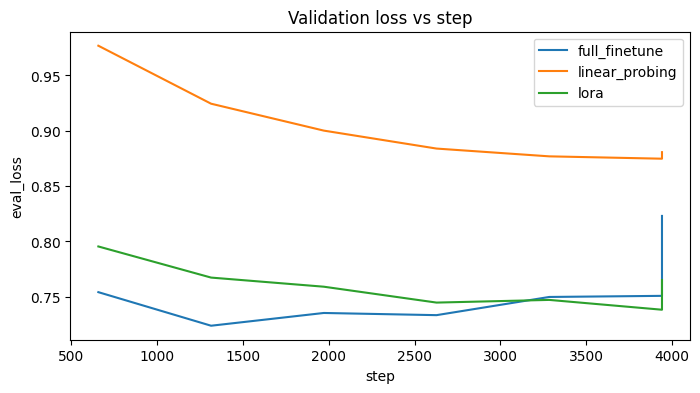

In [24]:
import matplotlib.pyplot as plt


def extract_curve(
    log_history: List[Dict[str, Any]],
    key: str,
) -> Tuple[List[float], List[float]]:
    xs: List[float] = []
    ys: List[float] = []
    for row in log_history:
        if key in row and 'step' in row:
            xs.append(float(row['step']))
            ys.append(float(row[key]))
    return xs, ys


plt.figure(figsize=(8, 4))
for r in results:
    x, y = extract_curve(r.log_history, 'eval_loss')
    if len(x) == 0:
        continue
    plt.plot(x, y, label=r.name)
plt.title('Validation loss vs step')
plt.xlabel('step')
plt.ylabel('eval_loss')
plt.legend()
plt.show()


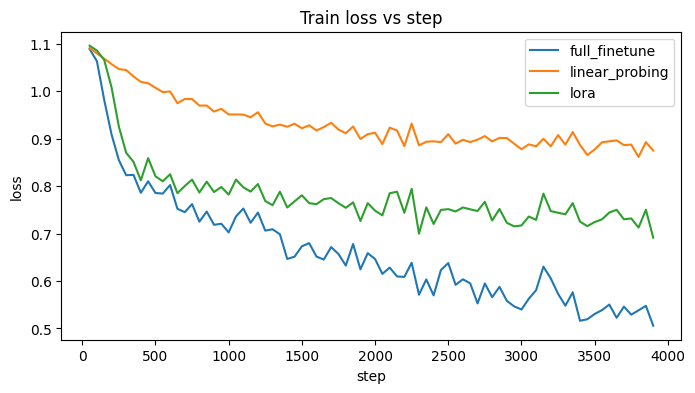

In [25]:
plt.figure(figsize=(8, 4))
for r in results:
    x, y = extract_curve(r.log_history, 'loss')
    if len(x) == 0:
        continue
    plt.plot(x, y, label=r.name)
plt.title('Train loss vs step')
plt.xlabel('step')
plt.ylabel('loss')
plt.legend()
plt.show()


# Выводы и обоснования решений
Была обучена трансформерная модель для 3-классовой классификации тональности и проведены три режима обучения: **full fine-tuning**, **linear probing** и **LoRA** и измерено качество **as-is** до дообучения.

Бейзлайн без обучения показал ожидаемо низкие метрики из-за случайно инициализированной классификационной головы, после чего все методы дообучения дали заметный прирост качества.

Наилучший результат по итоговым метрикам продемонстрировал **full fine-tuning**, **LoRA** показал близкое качество при меньшем числе обучаемых параметров и более быстром обучении, а **linear probing** оказался самым быстрым, но и самым слабым по качеству.

Сходимость и время обучения также ожидаемо различались: full обучался дольше, LoRA — средняя скорость, linear probing - самый быстрый.

Качество можно повысить, если выбрать **более крупную модель**: такие архитектуры обычно дают лучший прирост метрик на тональности, особенно на длинных отзывах. Однако это потребует **более мощной видеокарты**, большего объёма памяти и **больше времени** на обучение и подбор гиперпараметров.
